In [1]:
# no knowlege and prior knowlege
# raw vs modeled probability of noise complaints with reason compared to other mean days in the week

import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
from helpers import prep_the_data
import matplotlib.pyplot as plt
from helpers import ( prep_the_data)

In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2022__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()

In [6]:
# categorical key
keys = df_puma_2022__2024["dow"].astype(str)
codes, dow_idx = np.unique(keys, return_inverse=True)
coords = {"dow": codes}

In [7]:
# On a given weekday night in the summer, what is the probibility of a specific complaint

In [8]:
y = (df_puma_2022__2024["complaint_count"].to_numpy() >= 1).astype("int8")


In [9]:

# categorical key
keys = df_puma_2022__2024["dow_complaint"].astype(str)  # or dow_complaint if you didn't collapse
codes, dow_complaint_idx = np.unique(keys, return_inverse=True)

coords = {"dow_complaint": codes}


In [10]:
y = df_puma_2022__2024["complaint_count"].to_numpy().astype("int32")

In [11]:
with pm.Model(coords=coords) as model_pois_1:
 
    log_mu = pm.Normal("log_mu", 0, 2, dims="dow_complaint")
    
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims="dow_complaint")
    
    y_obs = pm.Poisson("y_obs", mu=mu[dow_complaint_idx], observed=y)
    
    idata_pois_1 = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_mu]


Output()

/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 192 seconds.


In [12]:
az.summary(idata_pois_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_mu[ANIMAL__Friday],0.130,0.043,0.049,0.209,0.001,0.001,6307.0,2921.0,1.0
log_mu[ANIMAL__Monday],0.134,0.041,0.055,0.210,0.001,0.001,5504.0,2866.0,1.0
log_mu[ANIMAL__Saturday],0.092,0.044,0.012,0.177,0.001,0.001,5382.0,3199.0,1.0
log_mu[ANIMAL__Sunday],0.121,0.043,0.041,0.203,0.001,0.001,6465.0,3247.0,1.0
log_mu[ANIMAL__Thursday],0.142,0.039,0.067,0.215,0.001,0.001,4932.0,3162.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[SOCIAL_PARTY__Saturday],5.679,0.018,5.647,5.712,0.000,0.000,6083.0,2862.0,1.0
mu[SOCIAL_PARTY__Sunday],6.173,0.018,6.139,6.208,0.000,0.000,6311.0,3217.0,1.0
mu[SOCIAL_PARTY__Thursday],2.835,0.014,2.809,2.862,0.000,0.000,5320.0,3274.0,1.0
mu[SOCIAL_PARTY__Tuesday],3.127,0.017,3.094,3.156,0.000,0.000,4334.0,3117.0,1.0


In [13]:
with model_pois_1:
    ppc_pois_1 = pm.sample_posterior_predictive(
        idata_pois_1,
        var_names=["y_obs"],
        random_seed=42
    )

Sampling: [y_obs]


Output()

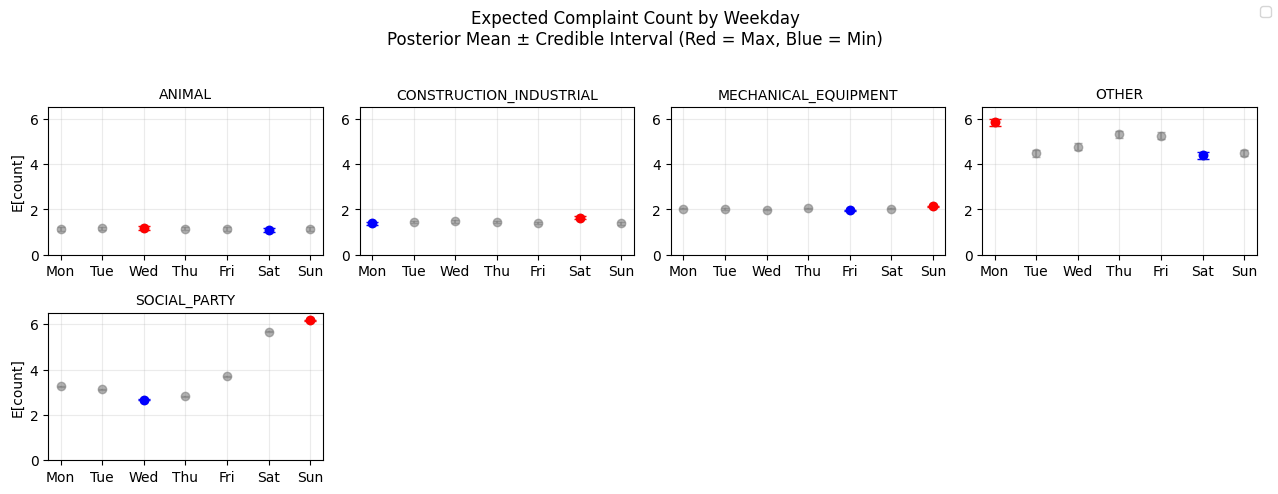

In [14]:
def plot_panel_mu_by_weekday(
    idata,
    *,
    dim_name="dow_complaint",
    mu_name="mu",
    sep="__",
    dow_order=("Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"),
    top_n=24,
    hdi=(0.05, 0.95),
    ncols=4,
    figsize_per_panel=(3.2, 2.4),
):
    mu_da = idata.posterior[mu_name]
    df = mu_da.to_dataframe(name="mu").reset_index()

    parts = df[dim_name].astype(str).str.rsplit(sep, n=1, expand=True)
    df["complaint"] = parts[0]
    df["dow"] = parts[1]

    df["dow"] = pd.Categorical(df["dow"], categories=list(dow_order), ordered=True)

    vc = df["complaint"].value_counts()
    complaints = vc.head(top_n).index.tolist() if top_n else vc.index.tolist()
    df = df[df["complaint"].isin(complaints)]

    q_lo, q_hi = hdi
    agg = (
        df.groupby(["complaint", "dow"])["mu"]
          .agg(mean="mean",
               low=lambda s: s.quantile(q_lo),
               high=lambda s: s.quantile(q_hi))
          .reset_index()
    )

    n = len(complaints)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig = plt.figure(figsize=(figsize_per_panel[0] * ncols,
                              figsize_per_panel[1] * nrows))

    y_max = agg["high"].max() * 1.05

    for i, comp in enumerate(complaints, start=1):
        ax = plt.subplot(nrows, ncols, i)

        sub = (
            agg[agg["complaint"] == comp]
            .set_index("dow")
            .reindex(list(dow_order))
        )

        x = np.arange(len(dow_order))
        y = sub["mean"].to_numpy()
        low = sub["low"].to_numpy()
        high = sub["high"].to_numpy()

        valid = np.isfinite(y) & np.isfinite(low) & np.isfinite(high)
        xv = x[valid]
        yv = y[valid]

        # Base (gray)
        ax.errorbar(
            xv, yv,
            yerr=np.vstack([yv - low[valid], high[valid] - yv]),
            fmt="o",
            color="gray",
            alpha=0.6,
            capsize=3,
        )

        # Identify min / max
        imax = xv[np.nanargmax(yv)]
        imin = xv[np.nanargmin(yv)]

        # Max (red)
        ax.errorbar(
            imax, y[imax],
            yerr=[[y[imax] - low[imax]], [high[imax] - y[imax]]],
            fmt="o",
            color="red",
            capsize=4,
            label="Max" if i == 1 else None,
        )

        # Min (blue)
        ax.errorbar(
            imin, y[imin],
            yerr=[[y[imin] - low[imin]], [high[imin] - y[imin]]],
            fmt="o",
            color="blue",
            capsize=4,
            label="Min" if i == 1 else None,
        )

        ax.set_xticks(x)
        ax.set_xticklabels([d[:3] for d in dow_order])
        ax.set_ylim(0, y_max)
        ax.set_title(comp, fontsize=10)
        ax.grid(True, alpha=0.25)

        if i % ncols == 1:
            ax.set_ylabel("E[count]")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(
        "Expected Complaint Count by Weekday\nPosterior Mean ± Credible Interval "
        "(Red = Max, Blue = Min)",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ---- Run it ----
plot_panel_mu_by_weekday(
    idata_pois_1,
    top_n=24,   # increase gradually; set None to try all (may be huge)
    ncols=4
)
